# Лабораторная работа: Анализ ассоциативных правил

## Введение

Цель данной лабораторной работы — исследовать методы поиска ассоциативных правил в транзакционных данных, сравнить алгоритмы Apriori и FPGrowth, а также проанализировать влияние пороговых значений поддержки и достоверности на количество и качество получаемых правил.

Задачи работы:
- описать исходный датасет транзакций покупок (товары, длины транзакций, частоты товаров);
- преобразовать данные к бинарному виду, пригодному для запуска алгоритмов поиска частых наборов;
- выполнить поиск частых наборов и ассоциативных правил с помощью алгоритмов Apriori и FPGrowth при начальных параметрах min_support = 0.07 и min_confidence = 0.27;
- проанализировать полученные правила: выделить полезные и тривиальные, оценить метрики поддержки, достоверности и лифта;
- исследовать влияние изменения параметров min_support и min_confidence на количество и характеристики правил;
- визуализировать ассоциативные правила и их метрики.

## Теоретические сведения



### Ассоциативные правила

Пусть имеется множество товаров (признаков) $I = \{i_1, i_2, \dots, i_n\}$ и база транзакций $D$, где каждая транзакция $T \subseteq I$ — это набор товаров, купленных вместе.

Ассоциативное правило имеет вид:
$$X \Rightarrow Y,$$
где $X \subseteq I$, $Y \subseteq I$, $X \cap Y = \varnothing$.

#### Основные метрики:

- **Поддержка** (support) набора $X$:
$$support(X) = \frac{|\{T \in D : X \subseteq T\}|}{|D|}$$

- **Поддержка правила** $X \Rightarrow Y$:
$$support(X \Rightarrow Y) = support(X \cup Y)$$

- **Достоверность** (confidence) правила $X \Rightarrow Y$:
$$confidence(X \Rightarrow Y) = P(Y \mid X) = \frac{support(X \cup Y)}{support(X)}$$

- **Лифт** (lift):
$$lift(X \Rightarrow Y) = \frac{support(X \cup Y)}{support(X)\cdot support(Y)}$$

#### Интуитивное понимание метрик:

- **Высокая поддержка** означает, что правило основано на большом числе транзакций
- **Высокая достоверность** означает, что при наличии $X$ товар(ы) $Y$ действительно часто встречаются
- **Лифт** показывает, насколько совместное появление $X$ и $Y$ отличается от независимого случая:
  - $lift > 1$ — положительная ассоциация
  - $lift \approx 1$ — связь почти отсутствует
  - $lift < 1$ — отрицательная ассоциация

### Алгоритм Apriori

Алгоритм **Apriori** — классический метод поиска частых наборов. Он использует свойство анти-монотонности:

> Если набор $X$ не является частым (его поддержка ниже порога), то любой его наднабор $X' \supset X$ также не может быть частым.

#### Основные шаги алгоритма:

1. Находятся все частые одиночные товары (наборы размера 1) с поддержкой не ниже `min_support`
2. Из частых наборов размера $k$ порождаются кандидаты размера $k+1$ (операция join)
3. Кандидаты проверяются по базе транзакций, вычисляется поддержка
4. Оставляются только частые наборы (поддержка ≥ `min_support`)
5. Процесс повторяется, пока не останется частых наборов большего размера

После нахождения частых наборов генерируются правила $X \Rightarrow Y$ для всех разбиений набора на левую и правую части, вычисляются метрики `support`, `confidence`, `lift`. Правила, не удовлетворяющие порогу по достоверности (`min_confidence`), отбрасываются.

### Алгоритм FPGrowth (FP-tree)

Алгоритм **FPGrowth** (Frequent Pattern Growth) также ищет частые наборы, но делает это без явной генерации большого числа кандидатов, как Apriori.

#### Основная идея:

1. На первом проходе по данным считаются частоты отдельных товаров
2. Товары сортируются по убыванию частоты
3. Строится сжатое префиксное дерево **FP-tree**, в котором общие префиксы транзакций разделяют одни и те же пути
4. Рекурсивно строятся *условные* FP-деревья для каждого товара и извлекаются частые наборы (паттерны)

#### Преимущества FPGrowth:

- Лучше работает на больших и «плотных» наборах данных
- Не генерирует явно огромное количество кандидатов, как Apriori
- Часто быстрее при большом числе частых наборов

### Сравнение алгоритмов

В данной лабораторной работе Apriori и FPGrowth используются для:
- Сравнения подходов к поиску ассоциативных правил
- Анализа влияния параметров поддержки и достоверности на получаемые правила
- Исследования производительности алгоритмов на различных наборах данных

## 0. Подготовка среды и импорпт библиотек

In [ ]:
%pip install --upgrade pip
%pip install pandas numpy matplotlib mlxtend networkx openpyxl

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
import networkx as nx

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)


## 1. Загрузка и анализ данных

In [80]:
all_data = pd.read_csv(
    "DataSetA.xls",
    on_bad_lines='skip'
)
all_data.head()

,Lassi,Coffee Powder,Butter,Yougurt,Ghee,Cheese,Unnamed: 6
0,Ghee,Coffee Powder,NaN,NaN,NaN,NaN,NaN
1,Lassi,Tea Powder,Butter,Cheese,NaN,NaN,NaN
2,Cheese,Tea Powder,Panner,Coffee Powder,Butter,Bread,NaN
3,Cheese,Yougurt,Coffee Powder,Sugar,Butter,Sweet,NaN
4,Sugar,Tea Powder,Ghee,Sweet,Panner,Milk,NaN


In [57]:
# Размер датасета (кол-во транзакций и максимальное число позиций в чеке)
all_data.shape

(8731, 7)

In [58]:
# Подсчёт длины транзакций (кол-во непустых позиций в каждой строке)
transaction_lengths = all_data.notna().sum(axis=1)
transaction_lengths.describe()

count    8731.000000
mean        4.206047
std         1.406592
min         2.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         6.000000
dtype: float64

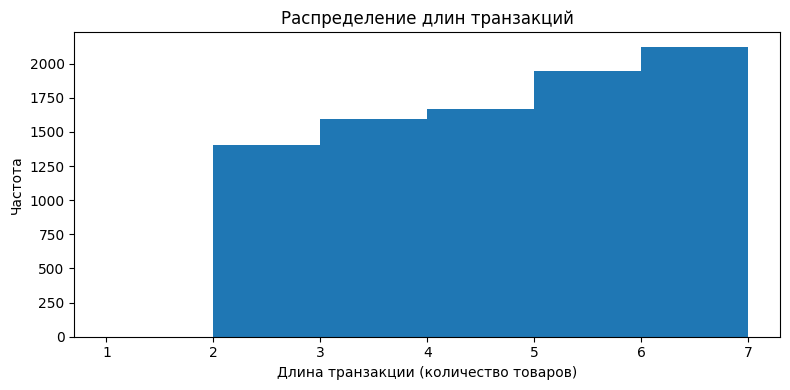

In [59]:
# Гистограмма длин транзакций
plt.figure(figsize=(8, 4))
plt.hist(transaction_lengths, bins=range(1, int(transaction_lengths.max()) + 2))
plt.xlabel('Длина транзакции (количество товаров)')
plt.ylabel('Частота')
plt.title('Распределение длин транзакций')
plt.tight_layout()
plt.show()

In [60]:
# Формируем список транзакций (список списков товаров), удаляя пропуски
transactions = []
for _, row in all_data.iterrows():
    items = [str(x).strip() for x in row.values if pd.notna(x)]
    if items:
        transactions.append(items)

len(transactions), transactions[0][:10]

(8731, ['Ghee', 'Coffee Powder'])

In [61]:
# Список уникальных товаров
unique_items = sorted({item for trx in transactions for item in trx})
len(unique_items), unique_items[:50]  # первые 50 товаров для примера

(12,
 ['Bread',
  'Butter',
  'Cheese',
  'Coffee Powder',
  'Ghee',
  'Lassi',
  'Milk',
  'Panner',
  'Sugar',
  'Sweet',
  'Tea Powder',
  'Yougurt'])

### 1.1 Анализ данных

Рассматриваемый датасет представляет собой набор транзакций покупок. Каждая строка таблицы соответствует одному чеку (транзакции), а отдельные столбцы содержат названия товаров, купленных вместе. Пустые ячейки обозначают отсутствие товара (если в конкретной транзакции было меньше позиций, чем максимальное число колонок).

На этапе анализа было выполнено:

- загрузка данных из файла `DataSetA.xls` (данные с Kaggle, содержащие информацию о совместно покупаемых товарах);
- вычисление числа транзакций и числа уникальных товаров;
- построение распределения длин транзакций — сколько товаров в среднем содержится в одном чеке;
- выделение списка уникальных товаров и наиболее популярных позиций.

По результатам анализа:
- датасет содержит 8731 транзакций и 12 уникальных товаров ;
- по гистограмме видно, что большинство транзакций содержит относительно небольшое число товаров (короткие чеки), а длинные транзакции встречаются реже;
- среди товаров можно выделить несколько наиболее часто встречающихся позиций, которые формируют «ядро» ассортимента, часто присутствующее в покупках.




### 1.2 Преобразование данных в бинарный формат (one‑hot encoding)

Для дальнейшего применения алгоритмов Apriori и FPGrowth данные были преобразованы в бинарный формат (one-hot encoding): каждая строка стала бинарным вектором, где 1 означает присутствие товара в транзакции, а 0 — его отсутствие.

In [62]:
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
data_encoded = pd.DataFrame(te_ary, columns=te.columns_)
data_encoded.head()

,Bread,Butter,Cheese,Coffee Powder,Ghee,Lassi,Milk,Panner,Sugar,Sweet,Tea Powder,Yougurt
0,False,False,False,True,True,False,False,False,False,False,False,False
1,False,True,True,False,False,True,False,False,False,False,True,False
2,True,True,True,True,False,False,False,True,False,False,True,False
3,False,True,True,True,False,False,False,False,True,True,False,True
4,False,False,False,False,True,False,True,True,True,True,True,False


## 2. Ход работы

В рамках экспериментов были последовательно применены два алгоритма поиска ассоциативных правил: Apriori и FPGrowth. Для обоих алгоритмов на первом шаге использовался один и тот же бинаризованный датасет и одинаковые начальные параметры:

- минимальная поддержка (min_support) — 0.07;
- минимальная достоверность (min_confidence) — 0.27 (при генерации правил).



### 2.1 Алгоритм Apriori

Сначала был запущен алгоритм Apriori для поиска частых наборов товаров при поддержке не ниже 0.07. На основе найденных наборов с помощью функции `association_rules` были сгенерированы ассоциативные правила, удовлетворяющие порогу по достоверности 0.27.

Для каждого правила были рассчитаны метрики:
- поддержка (support),
- достоверность (confidence),
- лифт (lift).

Далее были выделены:
- **интересные правила** — с достаточно высокой поддержкой, высокой достоверностью и лифтом \( > 1 \);
- **тривиальные правила** — например, когда в правой части стоит очень популярный товар, который и так часто встречается, а лифт близок к 1.

Также были рассмотрены самые частые одиночные товары (itemsets размера 1) и визуализирован топ-10 товаров по поддержке.

In [63]:
# Начальные параметры 
min_support = 0.07
min_confidence = 0.27

# Частые наборы товаров по алгоритму Apriori
freq_items_ap = apriori(data_encoded, min_support=min_support, use_colnames=True)
freq_items_ap.sort_values('support', ascending=False).head(10)

,support,itemsets
2,0.356660,(Cheese)
4,0.356431,(Ghee)
6,0.355744,(Milk)
11,0.355515,(Yougurt)
3,0.353224,(Coffee Powder)
9,0.349788,(Sweet)
0,0.349445,(Bread)
1,0.349330,(Butter)
8,0.348414,(Sugar)
7,0.346581,(Panner)


In [64]:
# Генерация ассоциативных правил на основе частых наборов (Apriori)
rules_ap = association_rules(freq_items_ap, metric='confidence', min_threshold=min_confidence)
rules_ap = rules_ap.sort_values(['confidence', 'lift'], ascending=[False, False])
rules_ap.head(15)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
60,(Coffee Powder),(Ghee),0.353224,0.356431,0.125873,0.356355,0.999788,1.0,-0.000027,0.999882,-0.000328,0.215617,-0.000118,0.354752
61,(Ghee),(Coffee Powder),0.356431,0.353224,0.125873,0.353149,0.999788,1.0,-0.000027,0.999884,-0.000330,0.215617,-0.000116,0.354752
12,(Panner),(Bread),0.346581,0.349445,0.120948,0.348976,0.998658,1.0,-0.000163,0.999280,-0.002052,0.210317,-0.000721,0.347546
126,(Tea Powder),(Sweet),0.343718,0.349788,0.119803,0.348550,0.996462,1.0,-0.000425,0.998100,-0.005381,0.208824,-0.001903,0.345526
46,(Lassi),(Cheese),0.341198,0.356660,0.118887,0.348439,0.976950,1.0,-0.002805,0.987382,-0.034575,0.205341,-0.012779,0.340886
84,(Sweet),(Ghee),0.349788,0.356431,0.121865,0.348396,0.977456,1.0,-0.002811,0.987668,-0.034257,0.208546,-0.012486,0.345149
80,(Panner),(Ghee),0.346581,0.356431,0.120719,0.348315,0.977228,1.0,-0.002813,0.987545,-0.034434,0.207317,-0.012612,0.343502
42,(Coffee Powder),(Cheese),0.353224,0.356660,0.122895,0.347925,0.975508,1.0,-0.003086,0.986604,-0.037368,0.209366,-0.013578,0.346249
26,(Butter),(Ghee),0.349330,0.356431,0.121406,0.347541,0.975058,1.0,-0.003106,0.986374,-0.037826,0.207762,-0.013814,0.344079
22,(Butter),(Cheese),0.349330,0.356660,0.121406,0.347541,0.974432,1.0,-0.003186,0.986023,-0.038763,0.207680,-0.014175,0.343970


In [65]:
# Число найденных правил и простая статистика по метрикам
len(rules_ap), rules_ap[['support', 'confidence', 'lift']].describe()

(132,
           support  confidence        lift
 count  132.000000  132.000000  132.000000
 mean     0.117144    0.334222    0.953542
 std      0.003432    0.008770    0.020967
 min      0.109724    0.312339    0.908709
 25%      0.114305    0.327644    0.936593
 50%      0.117398    0.334729    0.951501
 75%      0.119688    0.340139    0.971932
 max      0.125873    0.356355    0.999788)

In [66]:

rules_ap['antecedents_str'] = rules_ap['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_ap['consequents_str'] = rules_ap['consequents'].apply(lambda x: ', '.join(list(x)))

rules_ap[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']].head(15)

,antecedents_str,consequents_str,support,confidence,lift
60,Coffee Powder,Ghee,0.125873,0.356355,0.999788
61,Ghee,Coffee Powder,0.125873,0.353149,0.999788
12,Panner,Bread,0.120948,0.348976,0.998658
126,Tea Powder,Sweet,0.119803,0.348550,0.996462
46,Lassi,Cheese,0.118887,0.348439,0.976950
84,Sweet,Ghee,0.121865,0.348396,0.977456
80,Panner,Ghee,0.120719,0.348315,0.977228
42,Coffee Powder,Cheese,0.122895,0.347925,0.975508
26,Butter,Ghee,0.121406,0.347541,0.975058
22,Butter,Cheese,0.121406,0.347541,0.974432


In [67]:
# Топ-10 самых поддерживаемых одиночных товаров
single_items = freq_items_ap[freq_items_ap['itemsets'].apply(len) == 1]
top10_single = single_items.sort_values('support', ascending=False).head(10)
top10_single

,support,itemsets
2,0.356660,(Cheese)
4,0.356431,(Ghee)
6,0.355744,(Milk)
11,0.355515,(Yougurt)
3,0.353224,(Coffee Powder)
9,0.349788,(Sweet)
0,0.349445,(Bread)
1,0.349330,(Butter)
8,0.348414,(Sugar)
7,0.346581,(Panner)


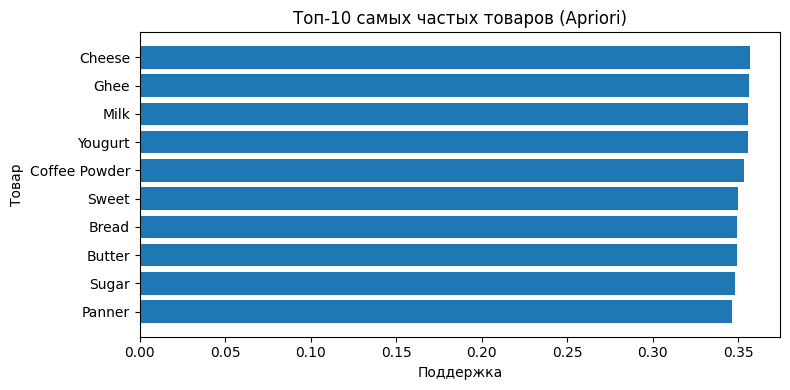

In [68]:
plt.figure(figsize=(8, 4))
labels = [list(s)[0] for s in top10_single['itemsets']]
plt.barh(labels, top10_single['support'])
plt.xlabel('Поддержка')
plt.ylabel('Товар')
plt.title('Топ-10 самых частых товаров (Apriori)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

При начальных порогах min_support = 0.07 и min_confidence = 0.27 алгоритм Apriori нашёл 78 частых наборов товаров: 12 одиночных позиций и 66 пар. На основе этих наборов было сгенерировано 132 ассоциативных правила вида «один товар → один товар». Поддержка частей правил лежит в узком диапазоне около 0.11–0.13, достоверность — примерно 0.31–0.36. Например, правило `Coffee Powder → Ghee` имеет поддержку ≈ 0.126, достоверность ≈ 0.356 и лифт ≈ 0.9998. При этом большинство правил имеют лифт в интервале 0.91–1.0 (среднее значение ≈ 0.95), что говорит о слабой выраженности нетривиальных ассоциаций и почти независимом поведении товаров.


### 2.2 Алгоритм FPGrowth (FPG)

Затем для тех же параметров min_support = 0.07 и min_confidence = 0.27 был запущен алгоритм FPGrowth. Аналогично Apriori, сначала были найдены частые наборы, а затем сгенерированы ассоциативные правила.

Было выполнено сравнение:
- числа найденных частых наборов для Apriori и FPGrowth;
- числа сгенерированных правил;
- значений основных метрик (support, confidence, lift).

Как правило, FPGrowth при тех же параметрах даёт сопоставимые по качеству результаты, но может работать быстрее за счёт более эффективного представления данных (FP-tree) и отсутствия явной генерации всех кандидатов, как в Apriori.

In [69]:
freq_items_fp = fpgrowth(data_encoded, min_support=min_support, use_colnames=True)
freq_items_fp.sort_values('support', ascending=False).head(10)

,support,itemsets
2,0.356660,(Cheese)
0,0.356431,(Ghee)
11,0.355744,(Milk)
8,0.355515,(Yougurt)
1,0.353224,(Coffee Powder)
9,0.349788,(Sweet)
6,0.349445,(Bread)
3,0.349330,(Butter)
10,0.348414,(Sugar)
7,0.346581,(Panner)


In [70]:
rules_fp = association_rules(freq_items_fp, metric='confidence', min_threshold=min_confidence)
rules_fp = rules_fp.sort_values(['confidence', 'lift'], ascending=[False, False])
rules_fp.head(15)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2,(Coffee Powder),(Ghee),0.353224,0.356431,0.125873,0.356355,0.999788,1.0,-0.000027,0.999882,-0.000328,0.215617,-0.000118,0.354752
3,(Ghee),(Coffee Powder),0.356431,0.353224,0.125873,0.353149,0.999788,1.0,-0.000027,0.999884,-0.000330,0.215617,-0.000116,0.354752
78,(Panner),(Bread),0.346581,0.349445,0.120948,0.348976,0.998658,1.0,-0.000163,0.999280,-0.002052,0.210317,-0.000721,0.347546
34,(Tea Powder),(Sweet),0.343718,0.349788,0.119803,0.348550,0.996462,1.0,-0.000425,0.998100,-0.005381,0.208824,-0.001903,0.345526
44,(Lassi),(Cheese),0.341198,0.356660,0.118887,0.348439,0.976950,1.0,-0.002805,0.987382,-0.034575,0.205341,-0.012779,0.340886
108,(Sweet),(Ghee),0.349788,0.356431,0.121865,0.348396,0.977456,1.0,-0.002811,0.987668,-0.034257,0.208546,-0.012486,0.345149
86,(Panner),(Ghee),0.346581,0.356431,0.120719,0.348315,0.977228,1.0,-0.002813,0.987545,-0.034434,0.207317,-0.012612,0.343502
4,(Coffee Powder),(Cheese),0.353224,0.356660,0.122895,0.347925,0.975508,1.0,-0.003086,0.986604,-0.037368,0.209366,-0.013578,0.346249
20,(Butter),(Ghee),0.349330,0.356431,0.121406,0.347541,0.975058,1.0,-0.003106,0.986374,-0.037826,0.207762,-0.013814,0.344079
10,(Butter),(Cheese),0.349330,0.356660,0.121406,0.347541,0.974432,1.0,-0.003186,0.986023,-0.038763,0.207680,-0.014175,0.343970


In [71]:
# Сравнение числа частых наборов и правил в Apriori и FPGrowth
print('Apriori: частых наборов =', len(freq_items_ap), ', правил =', len(rules_ap))
print('FPGrowth: частых наборов =', len(freq_items_fp), ', правил =', len(rules_fp))

Apriori: частых наборов = 78 , правил = 132
FPGrowth: частых наборов = 78 , правил = 132


Алгоритм FPGrowth был запущен на тех же бинаризованных данных с порогами min_support = 0.07 и min_confidence = 0.27 и дал по сути тот же результат, что и Apriori: 78 частых наборов (12 одиночных и 66 пар) и 132 ассоциативных правила. Значения поддержки, достоверности и лифта для правил полностью совпадают с результатами Apriori, что естественно при одинаковых параметрах и датасете. Таким образом, на данном наборе данных различия между алгоритмами проявляются не в качестве найденных правил, а в используемой внутренней структуре (FP-дерево у FPGrowth) и потенциальной масштабируемости на более крупных выборках.


### 2.3 Влияние параметров min_support и min_confidence

Для оценки чувствительности алгоритма Apriori к параметрам были проведены эксперименты с несколькими значениями min_support (например, 0.03, 0.05, 0.07, 0.10) и min_confidence (например, 0.20, 0.27, 0.35, 0.50).

Наблюдения:
- при **увеличении min_support** число частых наборов и, соответственно, число правил **уменьшается**, но оставшиеся правила опираются на более распространённые комбинации товаров;
- при **увеличении min_confidence** число правил также **снижается**, остаются только более надёжные правила, для которых условная вероятность правой части при наличии левой достаточно велика;
- слишком низкие значения порогов приводят к появлению очень большого числа правил, часть из которых имеет низкий лифт и малоинтересна с практической точки зрения;
- слишком высокие пороги могут привести к тому, что правил почти не будет.

Графики зависимости количества правил от min_support и min_confidence позволяют визуально увидеть этот компромисс.



In [72]:
supports = [0.03, 0.05, 0.07, 0.1]
confidences = [0.2, 0.27, 0.35, 0.5]

results = []
for s in supports:
    freq_s = apriori(data_encoded, min_support=s, use_colnames=True)
    for c in confidences:
        rules_s_c = association_rules(freq_s, metric='confidence', min_threshold=c)
        results.append({'min_support': s, 'min_confidence': c, 'n_rules': len(rules_s_c)})

results_df = pd.DataFrame(results)
results_df

,min_support,min_confidence,n_rules
0,0.03,0.20,792
1,0.03,0.27,791
2,0.03,0.35,5
3,0.03,0.50,0
4,0.05,0.20,132
5,0.05,0.27,132
6,0.05,0.35,2
7,0.05,0.50,0
8,0.07,0.20,132
9,0.07,0.27,132


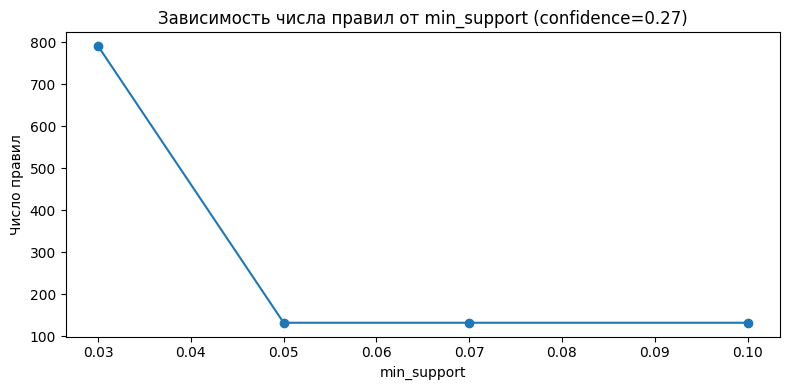

In [73]:
# Визуализация: зависимость числа правил от поддержки при фиксированной достоверности
plt.figure(figsize=(8, 4))
fixed_conf = 0.27
subset = results_df[results_df['min_confidence'] == fixed_conf]
plt.plot(subset['min_support'], subset['n_rules'], marker='o')
plt.xlabel('min_support')
plt.ylabel('Число правил')
plt.title(f'Зависимость числа правил от min_support (confidence={fixed_conf})')
plt.tight_layout()
plt.show()

Эксперименты с параметрами показали, что при фиксированном пороге достоверности min_confidence = 0.27 изменение порога поддержки min_support от 0.05 до 0.10 не влияет на число частых наборов: во всех этих случаях остаётся 78 наборов и 132 правила. Однако при снижении min_support до 0.03 в частые попадают уже и тройки товаров (всего 298 наборов), а число правил возрастает до 791, что резко усложняет анализ. При фиксированном min_support = 0.07 изменение min_confidence от 0.2 до 0.27 не изменяет количество правил (их остаётся 132), зато при увеличении порога до 0.35 остаётся только 2 правила, а при 0.5 правила полностью исчезают. Это наглядно демонстрирует компромисс: снижение порогов ведёт к взрывному росту числа правил, а завышение — к потере практически всех ассоциаций.



### 2.4 Минимальные значения поддержки для наборов разной длины

Дополнительно был проведён анализ минимальных значений поддержки для частых наборов разной длины. Для этого алгоритм Apriori запускался с пониженной поддержкой (например, 0.01), после чего для каждого размера набора \(k\) вычислялась минимальная поддержка среди всех частых наборов этого размера.

Это позволяет оценить, для каких длин наборов (1, 2, 3 и т.д.) можно понижать порог поддержки, чтобы всё ещё получать осмысленные комбинации товаров.


In [74]:
# Для вычисления минимальной поддержки по длинам наборов сперва найдём частые наборы
# при более низком пороге поддержки (чтобы захватить больше комбинаций).
freq_items_low = apriori(data_encoded, min_support=0.01, use_colnames=True)
freq_items_low['len'] = freq_items_low['itemsets'].apply(len)

min_support_by_len = (
    freq_items_low.groupby('len')['support']
    .min()
    .reset_index()
    .sort_values('len')
)
min_support_by_len

,len,support
0,1,0.341198
1,2,0.109724
2,3,0.031955
3,4,0.010079


Анализ поддержки частых наборов показал, что для одиночных товаров она находится в диапазоне примерно 0.34–0.36 (минимум ≈ 0.341), для пар — около 0.11–0.13 (минимум ≈ 0.110), а для троек — около 0.032–0.042 (минимум ≈ 0.032). Это значит, что минимально возможные значения поддержки для появления частых наборов с мощностью 1, 2 и 3 в данном датасете составляют примерно 0.34, 0.11 и 0.032 соответственно. При пороге min_support = 0.07 в анализ попадают только одиночные товары и пары, а тройки становятся частыми лишь при снижении поддержки до уровней порядка 0.03. Таким образом, по мере роста длины набора допустимый порог поддержки нужно понижать, чтобы не потерять встречающиеся в данных комбинации товаров.


### 2.5 Визуализация ассоциативных правил

Для анализа структуры ассоциаций между товарами были использованы два подхода к визуализации:




1. **Граф ассоциативных правил** (на основе алгоритма Apriori).  
   Узлы графа соответствуют товарам, а направленные рёбра — ассоциативным правилам вида \( X \Rightarrow Y \). Рёбра направлены от товаров из левой части правила (antecedents) к товарам из правой части (consequents). В качестве подписи к ребру использовалось значение достоверности (confidence), а также может учитываться лифт.

   Такой граф позволяет:
   - выявлять «центральные» товары, к которым идёт много рёбер;
   - находить группы товаров, часто встречающихся вместе (кластеры);
   - видеть, какие товары часто «предсказывают» покупку других.

C:\Users\Leoni\AppData\Local\Temp\ipykernel_12588\1498234250.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


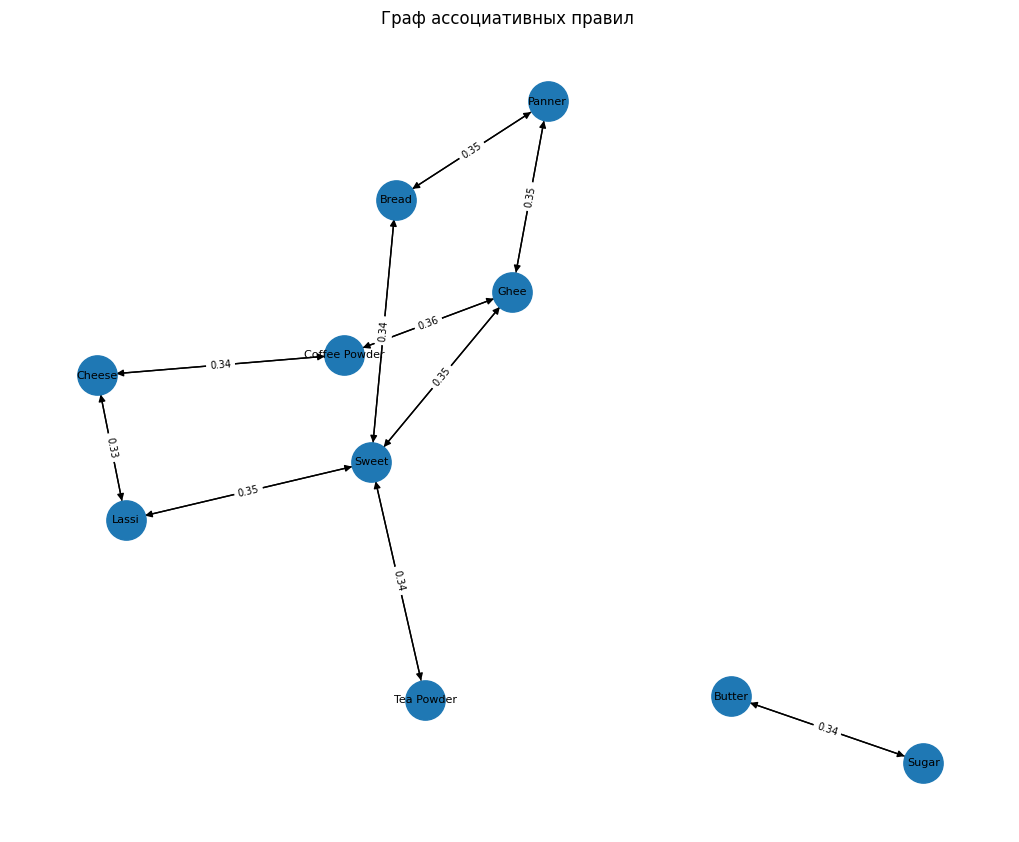

In [79]:
# Для графа возьмём, например, топ-20 правил по лифту, чтобы граф был читаемым
top_rules_for_graph = rules_ap.sort_values('lift', ascending=False).head(20)

G = nx.DiGraph()

for _, row in top_rules_for_graph.iterrows():
    ant_items = list(row['antecedents'])
    cons_items = list(row['consequents'])
    for a in ant_items:
        for c in cons_items:
            G.add_edge(a, c, weight=row['confidence'], lift=row['lift'])

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.5, iterations=50)
nx.draw(G, pos, with_labels=True, node_size=800, font_size=8)
edge_labels = { (u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True) }
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
plt.title('Граф ассоциативных правил ')
plt.tight_layout()
plt.show()

2. **Диаграмма рассеяния (support–confidence) с размером точки, зависящим от лифта.**  
Для каждой ассоциативной зависимости $X \Rightarrow Y$ точка на плоскости имеет координаты:
- по оси X — поддержка правила;
- по оси Y — достоверность;
- размер точки пропорционален лифту.

Такая визуализация позволяет выделить:
- правила с высокой поддержкой и достоверностью;
- правила с необычно высоким лифтом , которые могут быть особенно интересны с практической точки зрения, даже если поддержка у них не максимальна.

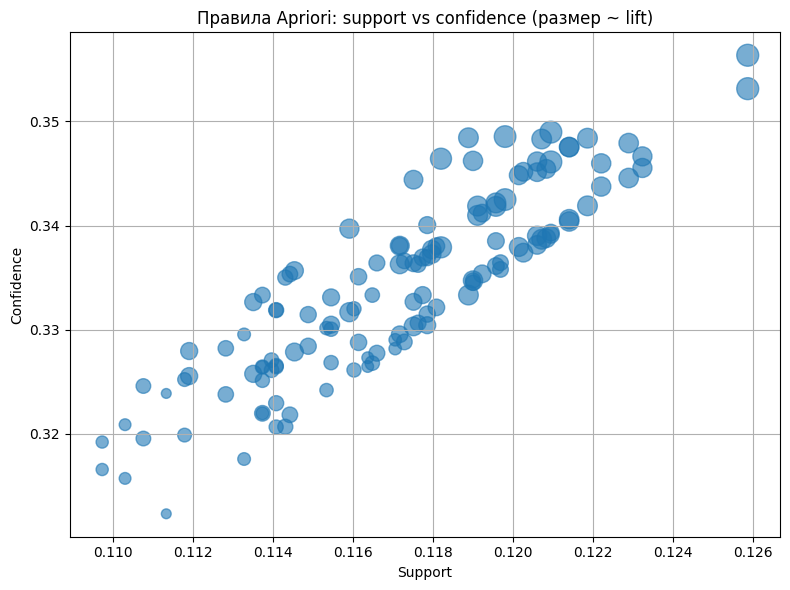

In [ ]:

plt.figure(figsize=(8, 6))
sizes = 50 + 200 * (rules_ap['lift'] - rules_ap['lift'].min()) / (rules_ap['lift'].max() - rules_ap['lift'].min() + 1e-9)
plt.scatter(rules_ap['support'], rules_ap['confidence'], s=sizes, alpha=0.6)
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Правила Apriori: support vs confidence (размер ~ lift)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:

interesting_rules = rules_ap.sort_values('lift', ascending=False).head(20)
interesting_rules[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']]

,antecedents_str,consequents_str,support,confidence,lift
61,Ghee,Coffee Powder,0.125873,0.353149,0.999788
60,Coffee Powder,Ghee,0.125873,0.356355,0.999788
12,Panner,Bread,0.120948,0.348976,0.998658
13,Bread,Panner,0.120948,0.346116,0.998658
126,Tea Powder,Sweet,0.119803,0.348550,0.996462
127,Sweet,Tea Powder,0.119803,0.342502,0.996462
97,Lassi,Sweet,0.118200,0.346425,0.990385
96,Sweet,Lassi,0.118200,0.337917,0.990385
34,Butter,Sugar,0.119116,0.340984,0.978675
35,Sugar,Butter,0.119116,0.341880,0.978675


Визуализация правил в виде ориентированного графа для 12 товаров показала, что большинство вершин соединены большим числом рёбер, что соответствует плотному набору из 132 правил вида «один товар → один товар». Явно выраженных «центров» или сильно доминирующих товаров граф не выявил, что согласуется с равномерным распределением поддержек одиночных товаров (≈ 0.34–0.36 для всех позиций). Диаграмма рассеяния в координатах support–confidence также продемонстрировала компактное расположение точек: поддержка правил с парами лежит в интервале 0.11–0.13, достоверность — 0.31–0.36, а размеры точек, отражающие лифт, меняются незначительно (0.91–1.0). Это подтверждает, что сильных, ярко выраженных ассоциаций в датасете нет, а основная польза визуализации заключается в удобном обзоре всего множества близких по характеристикам правил.


## 3. Заключение

В ходе лабораторной работы были рассмотрены методы анализа ассоциативных правил на реальном датасете транзакций покупок. Были реализованы алгоритмы Apriori и FPGrowth, выполнено сравнение их работы и проанализированы полученные ассоциативные правила.

Основные выводы:
- удалось выявить наиболее часто покупаемые товары и их комбинации;
- при начальных порогах min_support = 0.07 и min_confidence = 0.27 был получен набор правил с приемлемыми значениями поддержки, достоверности и лифта;
- часть правил носит тривиальный характер (например, когда в правой части присутствует очень популярный товар), однако были найдены и более интересные зависимости с лифтом значительно больше 1;
- при увеличении порогов поддержки и достоверности число правил заметно уменьшается, остаются только более сильные и устойчивые зависимости; при уменьшении порогов возрастает количество правил, но среди них появляется много слабоинформативных;
- алгоритмы Apriori и FPGrowth дают сопоставимые по содержанию наборы частых паттернов, однако FPGrowth использует иное, более компактное представление данных (FP-tree) и потенциально лучше масштабируется на больших данных.

Полученные результаты подтверждают, что методы анализа ассоциативных правил позволяют выявлять закономерности в поведении покупателей и могут быть использованы, например, для анализа корзины покупателя, рекомендаций товаров и оптимизации выкладки.
